# Kernel PCA


### Linear PCA
$\def\norm#1{\|#1\|}\def\pair#1{\langle #1 \rangle}\def\set#1{\lbrace#1\rbrace}$
$\def\RR{\mathbf{R}}$
$\def\trace{\operatorname{trace}}$

PCA is an unsupervised Machine Learning technique that learns a low-dimentional representation of the data.


We have a set $x_1,\ldots, x_m$ of vectors in $\RR^n$.

We project them to a lower dimention subspace spanned by the orthonormal vectors $v_1,\ldots,  v_k$.
For a single vector $x$, the projection is
$$
 P_V(x_i) = \sum_{i=1}^k \pair{x, v_i} v_i
$$
In matrix form, the orthogonal projection onto the span of $v$ is

$$
 P_V = V^TV
$$
where
$
 V = \lbrack v_1, \dots,  v_k \rbrack^T
$
satisfies $VV^T = I_k$. (since the $v_j$ are orthonormal).

In PCA, we try to find a subspace of dimensions $k$ such that the projection on this subspace is as close as possible to the original data, that is we solve:

$$
\min_{V} \frac{1}{2}\norm{X - V^TVX}^2
$$
over the orthonormal matrices $V$.
Apply pythagoria's theorem to split the norm:
$$
\frac{1}{2}\norm{X - V^TVX}^2 = \quad \frac{1}{2}\norm{X}^2 + \frac{1}{2}\norm{V^TV X}^2 - \pair{X, V^TVX}.
$$

The first term is constant with respect to $V$.
The second term is equal to $(1/2)\norm{V X}^2$ by isometry, and the last term
is $-\norm{VX}^2$.

Therfore the objective is also
$$
    \max_{V} \norm{VX}^2 = \max_{V} \trace{VX^TXV^T}
$$

We can show that in the last expression that $V$ is the top $k$-components of the
eigen decomposition of $XX^T$.

### PCA in a RKHS:

$\def\norm#1{\|#1\|}\def\pair#1{\langle #1 \rangle}\def\set#1{\lbrace#1\rbrace}$
$\def\RR{\mathbf{R}}$
$\def\trace{\operatorname{trace}}$
$\def\XX{\mathcal{X}}\def\HH{\mathcal{H}}$

We can proceed as before except that we try to find a $k$ dimentionnal representation of the vectors in the RKHS $\phi(x_1),...,\phi(x_n)$. The only difficulty is that those vectors are of infinite dimensions.

Let's first focus on the projection over a single vector ($k=1$). For a  unitary vector $f\in \HH$, $\norm{f}^2 = 1$, we can still define the projection
$$
P_f: \HH\to \HH ,\ g \mapsto \pair {g, f}f
$$
And the optimal vector is
$$
f^* = \argmin_{f \in \mathcal{H}, ||f|| = 1} \sum_{i=1}^n || P_f(\phi(x_i)) - \phi(x_i)||_\mathcal{H}^2
$$

Q1) Prove that

$$
f^* = \argmax_{f \in \mathcal{H}, ||f|| = 1} \sum_{i=1}^n f(x_i)^2
$$

(Tip: remember the reproducing property !)

### **Answer:**

In a RKHS, the orthogonal projection of $\phi(x_i)$ onto $f$ is:

$$
P_f(\phi(x_i)) = \langle \phi(x_i), f \rangle_{\mathcal{H}_k} f = f(x_i) f
$$

Compute the squared projection error:

$$
\|P_f(\phi(x_i)) - \phi(x_i)\|^2 = \|f(x_i)f - \phi(x_i)\|^2
$$

$$
\|P_f(\phi(x_i)) - \phi(x_i)\|^2 = f(x_i)^2\|f\|^2 - 2 f(x_i)\langle f, \phi(x_i) \rangle_{\mathcal{H}_k} + \|\phi(x_i)\|^2
$$

Thanks to the reproducing property: $ f(x_i) = \langle f, \phi(x_i) \rangle_{\mathcal{H}_k} $.

As $\|f\|^2 = 1$, we get then the final expression for squared projection error:

$$
\|P_f(\phi(x_i)) - \phi(x_i)\|^2 = \|\phi(x_i)\|^2 - f(x_i)^2
$$

Sum over all $i$:

$$
\sum_{i=1}^n \|P_f(\phi(x_i)) - \phi(x_i)\|^2 = \sum_{i=1}^n \|\phi(x_i)\|^2 - \sum_{i=1}^n f(x_i)^2
$$

Since $\sum \|\phi(x_i)\|^2$ does not depend on $f$, minimizing the total error is equivalent to maximizing:

$$
\sum_{i=1}^n f(x_i)^2
$$

Hence:

$$
f^* = \arg \max_{\|f\| = 1} \sum_i f(x_i)^2
$$

---

Q2) Let's prove a variant of the representer theorem for this new optimization problem. We split $\HH$ into the span of the $\phi(x_1),\ldots,\phi(x_m)$ and its complement, that is for each $f \in \mathcal{H}$ we denote

$$ f = f_X + f_\bot$$

where $f_X = \sum \alpha_i \phi(x_i)$ and $\langle f_\bot, f_X \rangle = 0$.

Prove the representer theorem i.e. that the optimal $f$ satisfies $f_\bot  = 0$.

### **Answer:**

$\quad \forall i, \langle f_\perp, \phi(x_i) \rangle = 0 $

So:

$$
f(x_i) = \langle f, \phi(x_i) \rangle = \langle f_X, \phi(x_i) \rangle + \underbrace{\langle f_\perp, \phi(x_i) \rangle}_{=0} = f_X(x_i)
$$

Sum over all i:

$$
\sum_{i=1}^n f(x_i)^2 = \sum_{i=1}^n f_X(x_i)^2
$$

which is independent of $f_\perp$.

Now since $\|f\|^2 = \|f_X\|^2 + \|f_\perp\|^2 \geq \|f_X\|^2$, the norm constraint $\|f\| = 1$ implies that $\|f_X\| \leq 1$.

I am now going to show that $f_\perp = 0$.

By absurd, suppose the optimum is achieved for some $f = f_X + f_\perp$ with $f_\perp \ne 0$.

I have:

$$
\|f\|^2 = \|f_X\|^2 + \|f_\perp\|^2 > \|f_X\|^2
$$

I can normalize $f_X$ to:

$$
\tilde{f}_X = \frac{f_X}{\|f_X\|}, \quad \text{so that } \|\tilde{f}_X\| = 1
$$

Then, because $\frac{1}{\|f_X\|^2} > 1$:

$$
\sum_i \tilde{f}_X(x_i)^2 = \frac{1}{\|f_X\|^2} \sum_i f_X(x_i)^2 > \sum_i f_X(x_i)^2 = \sum_i f(x_i)^2
$$

This **contradicts** the optimality of $f$.

To maximize the quantity $\sum f(x_i)^2$ under norm constraint, we must take:

$$
f_\perp = 0 \quad \Rightarrow \quad f = f_X
$$

To conclude:

The optimal $f$ lies in the span of $\phi(x_i)$, i.e.,

$$
f^* = f_X = \sum_{i=1}^n \alpha_i \phi(x_i)
$$

---

Q3) Apply the representer theorem to get a optimization problem over $\alpha \in \mathbb{R}^n$. As always the problem should depend only on $\alpha$ and the kernel matrix $K$.

### **Answer:**
Thanks to the previous question, we know that the optimal $f \in \mathcal{H}_k$ can be written as:

$$
f = \sum_{i=1}^n \alpha_i \phi(x_i)
$$



Then, the constraint becomes:

$$\|f\|_{\mathcal{H}_k}^2 = \| \sum_{i=1}^n \alpha_i \phi(x_i) \|_{\mathcal{H}_k}^2 $$

$$\|f\|_{\mathcal{H}_k}^2 = \langle \sum_{i=1}^n \alpha_i \phi(x_i), \sum_{j=1}^n \alpha_j \phi(x_j) \rangle $$

$$\|f\|_{\mathcal{H}_k}^2 = \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j \langle \phi(x_i), \phi(x_j) \rangle $$

$$\|f\|_{\mathcal{H}_k}^2 = \boldsymbol{\alpha}^\top K \boldsymbol{\alpha}$$

So:

$$
\boldsymbol{\alpha}^\top K \boldsymbol{\alpha} = 1
$$


Now, rewrite the objective with $\alpha \in \mathbb{R}^n$.

I use question 2 and the reproducing property. I can express:

$$f(x_j) = \langle \sum_{i=1}^n \alpha_i \phi(x_i), \phi(x_j) \rangle = \sum_{i=1}^n \alpha_i k(x_i,x_j) = (K \boldsymbol{\alpha})_j$$

The objective becomes:

$$
\sum_{i=1}^n f(x_i)^2 = \|K \boldsymbol{\alpha}\|^2 = \boldsymbol{\alpha}^\top K^2 \boldsymbol{\alpha}
$$

Finally, I get a optimization problem over $\alpha \in \mathbb{R}^n$:

$$
\max_{\boldsymbol{\alpha} \in \mathbb{R}^n}
\quad \boldsymbol{\alpha}^\top K^2 \boldsymbol{\alpha}
\quad \text{with the constraint} \quad
\boldsymbol{\alpha}^\top K \boldsymbol{\alpha} = 1
$$

---

Q4) Use the change of variable $\beta = \sqrt{K} \alpha$ to rewrite the problem as an eigenvalue problem.

### **Answer:**

Since the Gram matrix $K$ is symmetric positive semi-definite, it admits a square root $\sqrt{K}$ via spectral decomposition. Thus, the change of variable $\beta = \sqrt{K} \alpha$ is well-defined on the image of $K$.

We use this change of variable in the previous question.

The objective becomes:

$$
\alpha^\top K^2 \alpha
= \beta^\top K \beta
$$

The constraint becomes:

$$
\alpha^\top K \alpha
= \beta^\top \beta = \|\beta\|^2 = 1
$$

Finally, we get the eigenvalue problem:

$$
\max_{\|\beta\| = 1} \quad \beta^\top K \beta
$$

which is maximized by the eigenvector $\beta^*$ of $K$ corresponding to its largest eigenvalue.

---

Q5) Let's say that we have found the $k$ principal vectors $f_1,...,f_k$ and that they all have the form

$$f_j = \sum_i \alpha_{i,j} \phi(x_i)$$

We are now given an new point $x$ (not necessarily in the train set). Give the expression of the $k$ principal components of $\phi(x)$:

$$ f_j(x) = \langle \phi(x), f_j \rangle$$

Give the expression of vector $f(x)$ depending on the matrix $\alpha$ and the vector $k_x = [k(x,x_1),...,k(x,x_n)]$

### **Answer:**

A representer vector has the form:

$$
f_j = \sum_i \alpha_{i,j} \phi(x_i)
$$

And:

$$
u(x)_j = \langle \phi(x), f_j \rangle_{\mathcal{H}_k}
$$

By substituting $f_j$, we get:

$$
u(x)_j = \left\langle \phi(x), \sum_i \alpha_{i,j} \phi(x_i) \right\rangle_{\mathcal{H}_k}
= \sum_i \alpha_{i,j} \langle \phi(x), \phi(x_i) \rangle_{\mathcal{H}_k}
= \sum_i \alpha_{i,j} k(x, x_i)
= (\boldsymbol{\alpha}^\top k_x)_j
$$

We can conclude:

$$
u(x) = \boldsymbol{\alpha}^\top k_x
$$

---

In conclusion, the algorithm for kernel PCA is :

* compute the gram matrix and center it.
* decompose it, keep the first $k$ eigenvectors, and eigenvalues.
* At a test point $x$, compute the k principal components.

### Code Session

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

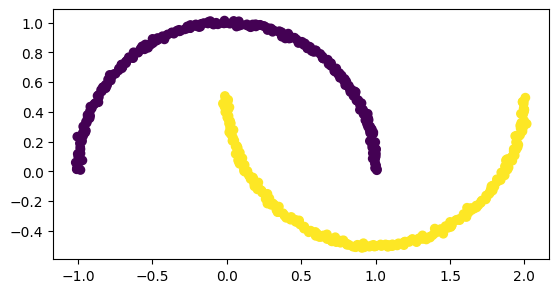

In [11]:
random_state = 17
n_samples = 500
X, y = make_moons(n_samples=n_samples, noise=0.01, random_state=random_state)
#X, y = make_circles(n_samples=n_samples, noise=0.01, factor=0.3, random_state=random_state)
#X, y = make_blobs(n_samples=n_samples, centers=3, cluster_std=1.0, random_state=random_state)

fig, ax = plt.subplots()
_ = ax.scatter(X[:,0], X[:,1], c=y)
ax.set_aspect('equal')

In [12]:
def make_grid(n,X):
    """
        Generates a grid of points within the bounds of the given data.

        n : int
            The number of points along each dimension of the grid.
        X : numpy.ndarray
            A 2D array of shape (num_samples, 2) representing the input data.

        numpy.ndarray
            A 2D array of shape (n*n, 2) containing the grid points.
    """
    x_min, y_min = np.min(X, axis=0)
    x_max, y_max = np.max(X, axis=0)
    xy = np.mgrid[x_min:x_max:1j*n, y_min:y_max:1j*n].reshape(2,-1).T
    return xy

In [13]:
class Kernel():

    def compute_norm_f(self, Kxx, alpha):
        '''
        Input:
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            norm_f: float
        '''

        norm_f = alpha.T @ Kxx @ alpha

        return norm_f

    def compute_prediction_train(self, Kxx, alpha):
        '''
        Input:
            Kxx: numpy array of shape (n, n)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (n)
        '''

        y = Kxx @ alpha

        return y

    def compute_prediction_test(self, Kxz, alpha):
        '''
        Input:
            Kxz: numpy array of shape (n, m)
            alpha: numpy array of shape (n)
        Output:
            y: numpy array of shape (m)
        '''

        y = Kxz.T @ alpha

        return y


class GaussianKernel(Kernel):

    def __init__(self, sigma = 1):
        self.sigma = sigma

    def get_Kxx(self, X):
        '''
        Input:
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''

        sq_norms = np.sum(X**2, axis=1).reshape(-1, 1)
        dist = sq_norms + sq_norms.T - 2 * X @ X.T
        Kxx = np.exp(-dist / (2 * self.sigma**2))

        return Kxx

    def get_Kxz(self, X, Z):
        '''
        Input:
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''

        X_norm = np.sum(X**2, axis=1).reshape(-1, 1)  # (n, 1)
        Z_norm = np.sum(Z**2, axis=1).reshape(1, -1)  # (1, m)
        dist_sq = X_norm + Z_norm - 2 * X @ Z.T
        Kxz = np.exp(-dist_sq / (2 * self.sigma**2))

        return Kxz

class LinearKernel(Kernel):

    def __init__(self):
        pass

    def get_Kxx(self, X):
        '''
        Input:
            X: numpy array of shape (n, d)
        Output:
            Kxx: gnumpy array of shape (n, n)
        '''

        Kxx = X @ X.T

        return Kxx

    def get_Kxz(self, X, Z):
        '''
        Input:
            X: numpy array of shape (n, d)
            Z: numpy array of shape (m, d)
        Output:
            Kxz: gnumpy array of shape (n, m)
        '''

        Kxz = X @ Z.T

        return Kxz

In [14]:
def center_train_gram_matrix(Kxx):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
    Output:
        Kxx_c: numpy array of shape (n, n)
    '''

    Kxx_c = Kxx - np.mean(Kxx, axis=0, keepdims=True) - np.mean(Kxx, axis=1, keepdims=True) + np.mean(Kxx, keepdims=True)

    return Kxx_c

def center_test_gram_matrix(Kxx, Kxz):
    '''
    Input:
        Kxx: numpy array of shape (n, n)
        Kxz: numpy array of shape (n, m)
    Output:
        K_c: numpy array of shape (n, m)
    '''

    Kxz_c = Kxz - np.mean(Kxz, axis=0, keepdims=True) - np.mean(Kxx, axis=1, keepdims=True) + np.mean(Kxx, keepdims=True)

    return Kxz_c

In [15]:
# Hyperparameters (to be tuned)
kernel = 'linear' # test 'linear' or 'gaussian'
sigma = 1
lbda = 0.1

# Define kernel
if kernel == 'linear':
    kernel = LinearKernel()
elif kernel == 'gaussian':
    kernel = GaussianKernel(sigma = sigma)
else:
    raise ValueError('Unknown kernel')


def KPCA_representation(X):
    """
    Compute the finite-dimensional representation of the principal components.

    Parameters
    ----------
    X : (n, d) numpy.ndarray
        The input data.

    Returns
    -------
    alpha : (n, k) numpy.ndarray
        The finite-dimensional representation of the principal components.
    """
    # get the kernel matrix, center it, get the eigenvectors and eigenvalues, change the variables.
    Kxx = kernel.get_Kxx(X)
    Kxx_c = center_train_gram_matrix(Kxx)

    eigvals, eigvecs = np.linalg.eigh(Kxx_c)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    k_eff = np.sum(eigvals > 1e-12)
    eigvals = eigvals[:k_eff]
    V = eigvecs[:, :k_eff]

    alpha = V / np.sqrt(eigvals[None, :])
    return alpha

In [16]:
def principal_component(alpha, X, Z):
    """
    return the evaluation of the principal components at points Z.

    Parameters
    ----------
    alpha : (n, k) numpy.ndarray
        The finite-dimensional representation of the principal components
    X: (n, d) numpy.ndarray
        The input data.
    Z : (m, n) array
        points to where to evaluate the principal components.

    Returns
    -------
    (k, m) array
        value of the k principal components at points y.
    """
    Kxx = kernel.get_Kxx(X)
    Kxz = kernel.get_Kxz(X, Z)
    Kxz_c = center_test_gram_matrix(Kxx, Kxz)

    Y = alpha.T @ Kxz_c
    return Y

In [18]:
n_eval = 200
Z = make_grid(n_eval, X)

alpha = KPCA_representation(X)
principal_component_fn = lambda E: principal_component(alpha, X, E)
feval = principal_component_fn(Z)
fself = principal_component_fn(X)

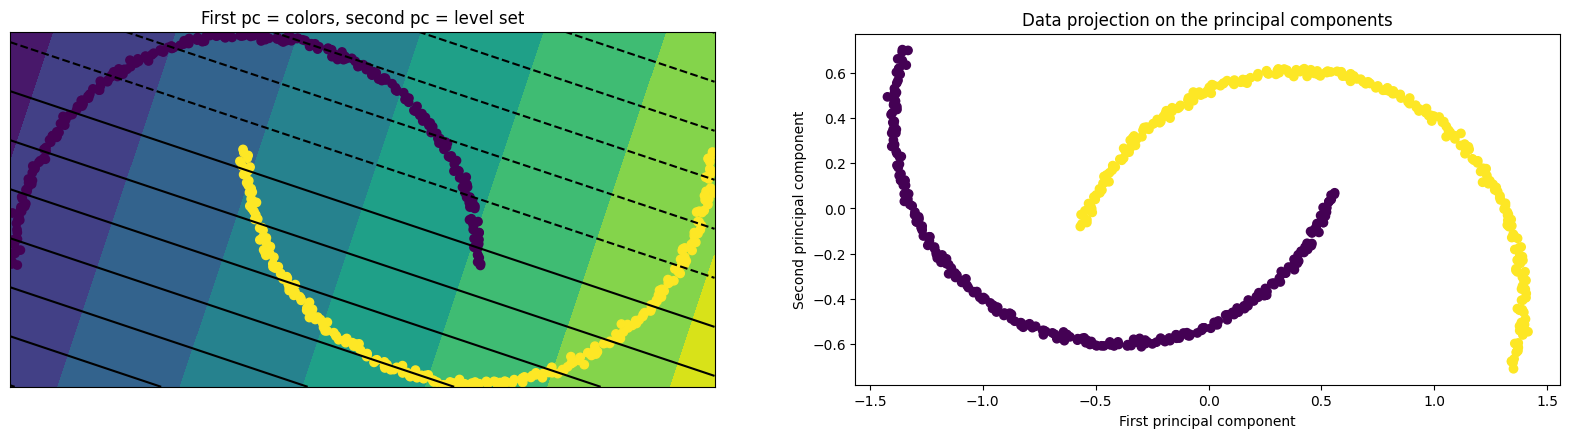

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
Ep = Z.T.reshape((2, n_eval, n_eval))
fxp = feval.reshape((feval.shape[0], n_eval, n_eval))
_ = ax1.contourf(Ep[0], Ep[1], fxp[0])
_ = ax1.contour(Ep[0], Ep[1], fxp[1], colors='black', levels=12 )
_ = ax1.scatter(X[:,0], X[:,1], c=y)
ax2.scatter(fself[0], fself[1], c=y)
ax1.xaxis.set_visible(False)
ax1.yaxis.set_visible(False)
#ax2.xaxis.set_visible(False)
#ax2.yaxis.set_visible(False)
ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax1.set_title('First pc = colors, second pc = level set')
ax2.set_title('Data projection on the principal components')
ax2.set_xlabel('First principal component')
ax2.set_ylabel('Second principal component')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
plt.show()